## Descobertas Iniciais

O grupo de imagens de lifestyle apresentou maior CTR, maior taxa de conversão, maior tempo médio na página e maior receita por usuário em comparação ao grupo de imagens em estúdio.

Nesta etapa, os resultados sugerem que as imagens em estilo de vida podem performar melhor do que as imagens em estúdio. No entanto, esta análise exploratória não comprova significância estatística. O próximo passo é aplicar testes de hipóteses para avaliar se as diferenças observadas são estatisticamente relevantes.

## Initial Findings

The lifestyle image group showed higher CTR, higher conversion rate, longer average time on page, and higher revenue per user compared to the studio image group.

At this stage, the results suggest that lifestyle images may perform better than studio images. However, this exploratory analysis does not prove statistical significance. The next step is to apply hypothesis tests to evaluate whether the observed differences are statistically meaningful.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ab_visual_assets.csv")

In [3]:
df.head()

,user_id,image_type,gender,age_group,customer_type,clicks,converted,time_on_page,purchase_value
0,1,studio,male,adult,new,0,0,40.41,0.0
1,2,lifestyle,male,young,new,0,0,45.43,0.0
2,3,lifestyle,male,young,returning,0,0,23.85,0.0
3,4,lifestyle,female,adult,new,0,0,38.83,0.0
4,5,studio,male,adult,new,0,0,46.64,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         10000 non-null  int64  
 1   image_type      10000 non-null  str    
 2   gender          10000 non-null  str    
 3   age_group       10000 non-null  str    
 4   customer_type   10000 non-null  str    
 5   clicks          10000 non-null  int64  
 6   converted       10000 non-null  int64  
 7   time_on_page    10000 non-null  float64
 8   purchase_value  10000 non-null  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 703.3 KB


In [13]:

df["image_type"].value_counts(normalize=True)

image_type
studio       0.5076
lifestyle    0.4924
Name: proportion, dtype: float64

In [14]:
summary_by_image = df.groupby("image_type").agg(
    users=("user_id", "count"),
    clicks=("clicks", "sum"),
    ctr=("clicks", "mean"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    avg_time_on_page=("time_on_page", "mean"),
    revenue=("purchase_value", "sum"),
    revenue_per_user=("purchase_value", "mean")
)

summary_by_image

,users,clicks,ctr,conversions,conversion_rate,avg_time_on_page,revenue,revenue_per_user
image_type,,,,,,,,
lifestyle,4924,545,0.110682,241,0.048944,45.387729,32875.56,6.676596
studio,5076,438,0.086288,205,0.040386,37.780780,26480.29,5.216763


In [15]:
summary_formatted = summary_by_image.copy()

summary_formatted["ctr"] = summary_formatted["ctr"].map(lambda x: f"{x:.2%}")
summary_formatted["conversion_rate"] = summary_formatted["conversion_rate"].map(lambda x: f"{x:.2%}")
summary_formatted["avg_time_on_page"] = summary_formatted["avg_time_on_page"].map(lambda x: f"{x:.2f}s")
summary_formatted["revenue"] = summary_formatted["revenue"].map(lambda x: f"R$ {x:,.2f}")
summary_formatted["revenue_per_user"] = summary_formatted["revenue_per_user"].map(lambda x: f"R$ {x:,.2f}")

summary_formatted

,users,clicks,ctr,conversions,conversion_rate,avg_time_on_page,revenue,revenue_per_user
image_type,,,,,,,,
lifestyle,4924,545,11.07%,241,4.89%,45.39s,"R$ 32,875.56",R$ 6.68
studio,5076,438,8.63%,205,4.04%,37.78s,"R$ 26,480.29",R$ 5.22


In [16]:
studio = summary_by_image.loc["studio"]
lifestyle = summary_by_image.loc["lifestyle"]

ctr_lift = (lifestyle["ctr"] - studio["ctr"]) / studio["ctr"]
conversion_lift = (lifestyle["conversion_rate"] - studio["conversion_rate"]) / studio["conversion_rate"]
rpu_lift = (lifestyle["revenue_per_user"] - studio["revenue_per_user"]) / studio["revenue_per_user"]

print(f"CTR lift: {ctr_lift:.2%}")
print(f"Conversion lift: {conversion_lift:.2%}")
print(f"Revenue per user lift: {rpu_lift:.2%}")

CTR lift: 28.27%
Conversion lift: 21.19%
Revenue per user lift: 27.98%


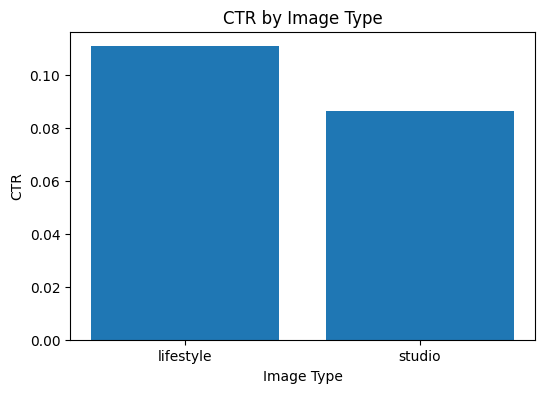

In [17]:
ctr = df.groupby("image_type")["clicks"].mean()

plt.figure(figsize=(6, 4))
plt.bar(ctr.index, ctr.values)
plt.title("CTR by Image Type")
plt.xlabel("Image Type")
plt.ylabel("CTR")
plt.show()

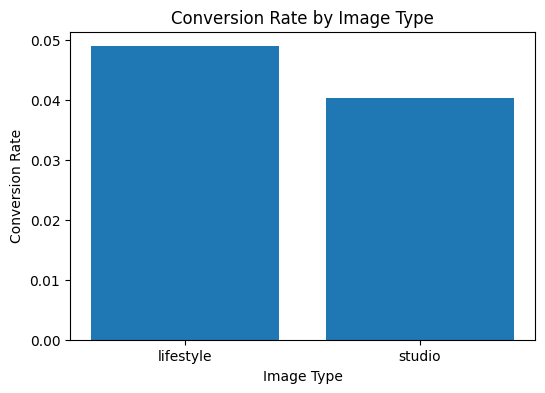

In [18]:
conversion = df.groupby("image_type")["converted"].mean()

plt.figure(figsize=(6, 4))
plt.bar(conversion.index, conversion.values)
plt.title("Conversion Rate by Image Type")
plt.xlabel("Image Type")
plt.ylabel("Conversion Rate")
plt.show()

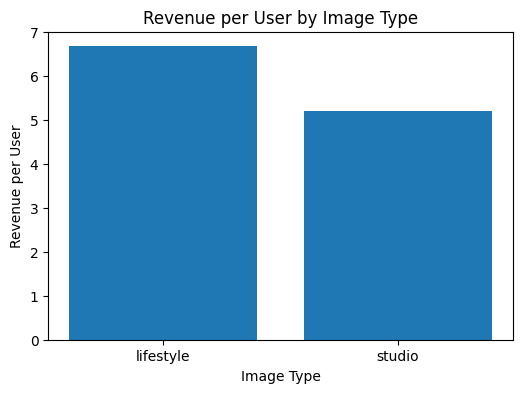

In [19]:
rpu = df.groupby("image_type")["purchase_value"].mean()

plt.figure(figsize=(6, 4))
plt.bar(rpu.index, rpu.values)
plt.title("Revenue per User by Image Type")
plt.xlabel("Image Type")
plt.ylabel("Revenue per User")
plt.show()